# Function 5 Analysis - Week 9

**Function description:**  
You're tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

**Week 8 evaluated point:** `(0.241596, 0.899190, 0.999688, 1.000000)` returned **y = 3327.43** — a **new maximum!** Up from 3136 last week. Total observations: **27**.

**This is working!** We've been climbing steadily:
- Week 6: 2981.55
- Week 7: 3136.42 (new max)
- Week 8: 3327.43 (new max again!)

The pattern is clear: **low x1 + high x2/x3/x4 = high yield**. Each week we push x2 a bit higher, and the yield keeps climbing.

---

### Recommendation for Week 9: Keep Riding the Ridge

**Why change what's working?** The GP-based approach with `x234_prod` constraint is perfect for this unimodal function. I'll keep the same methodology.

**The ridge pattern:**
- x1 should stay LOW (around 0.24)
- x2 should keep INCREASING (was 0.875 -> 0.899, try 0.92-0.95 next)
- x3 and x4 should stay at or near 1.0

**My plan:**
- Continue using GP with Expected Improvement (EI)
- Keep the `x234_prod >= 0.82` constraint to stay on the ridge
- Push x2 higher (search in 0.90-0.98 range)
- Add small jitter to avoid re-sampling the exact same point

**Where is the peak?** If the pattern continues, the optimum might be at the corner: `(x1~0.24, x2~1.0, x3=1.0, x4=1.0)`. Let's see if x2 can go even higher!


## Loading and Displaying the Data

We load the inputs and outputs for function 5. Best outputs stay on the low-x1 / high-x2–x4 ridge. Week 7 `(0.242550, 0.875768, 1.000000, 1.000000)` returned **≈3136.42 (new max)**, topping Week 6’s ≈2981.55. Total observations: **27**.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_5")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.191447, 0.846480, 0.879484, 0.878516]])
y_new_point_week_1 = np.array([1086.3644542213872])
X_new_point_week_2 = np.array([[0.202624, 0.849188, 0.971974, 0.920186]])
y_new_point_week_2 = np.array([1935.0092608386958])
X_new_point_week_3 = np.array([[0.203491, 0.849529, 0.982723, 0.925116]])
y_new_point_week_3 = np.array([2066.674475985541])
X_new_point_week_4 = np.array([[0.206189, 0.850311, 1.000000, 0.936243]])
y_new_point_week_4 = np.array([2323.4365797217065])
X_new_point_week_5 = np.array([[0.218976, 0.853432, 1.000000, 0.979950]])
y_new_point_week_5 = np.array([2748.829971152165])
X_new_point_week_6 = np.array([[0.225152, 0.855580, 1.000000, 1.000000]])
y_new_point_week_6 = np.array([2981.55176998145])
X_new_point_week_7 = np.array([[0.242550, 0.875768, 1.000000, 1.000000]])
y_new_point_week_7 = np.array([3136.42])
X_new_point_week_8 = np.array([[0.241596, 0.899190, 0.999688, 1.000000]])
y_new_point_week_8 = np.array([3327.429213141313])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525
5,0.683432,0.118663,0.829046,0.567577,78.434389
6,0.553621,0.667350,0.323806,0.814870,57.571537
7,0.352356,0.322242,0.116979,0.473113,109.571876
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223610


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.241596,0.899190,0.999688,1.000000,3327.429213,0.785119
1,0.242550,0.875768,1.000000,1.000000,3136.420000,0.779579
2,0.225152,0.855580,1.000000,1.000000,2981.551770,0.770183
3,0.218976,0.853432,1.000000,0.979950,2748.829971,0.763090
4,0.206189,0.850311,1.000000,0.936243,2323.436580,0.748186
5,0.203491,0.849529,0.982723,0.925116,2066.674476,0.740215
6,0.202624,0.849188,0.971974,0.920186,1935.009261,0.735993
7,0.224189,0.846480,0.879484,0.878516,1088.859618,0.707167
8,0.191447,0.846480,0.879484,0.878516,1086.364454,0.698982
9,0.119879,0.862540,0.643331,0.849804,431.612757,0.618889


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [2]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 110)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 110)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.2f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.2f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,y,Running_Max,Status,Improvement
0,1,0.191447,0.846480,0.879484,0.878516,1086.364454,1086.364454,✓ NEW MAX,+1086.36
1,2,0.202624,0.849188,0.971974,0.920186,1935.009261,1935.009261,✓ NEW MAX,+848.64
2,3,0.203491,0.849529,0.982723,0.925116,2066.674476,2066.674476,✓ NEW MAX,+131.67
3,4,0.206189,0.850311,1.000000,0.936243,2323.436580,2323.436580,✓ NEW MAX,+256.76
4,5,0.218976,0.853432,1.000000,0.979950,2748.829971,2748.829971,✓ NEW MAX,+425.39
5,6,0.225152,0.855580,1.000000,1.000000,2981.551770,2981.551770,✓ NEW MAX,+232.72
6,7,0.242550,0.875768,1.000000,1.000000,3136.420000,3136.420000,✓ NEW MAX,+154.87
7,8,0.241596,0.899190,0.999688,1.000000,3327.429213,3327.429213,✓ NEW MAX,+191.01



📊 Summary: 8/8 weeks achieved new max (Weeks [1, 2, 3, 4, 5, 6, 7, 8])
   Success rate: 100.0% | Final best: 3327.43 | Improvement: 3.1x from Week 1


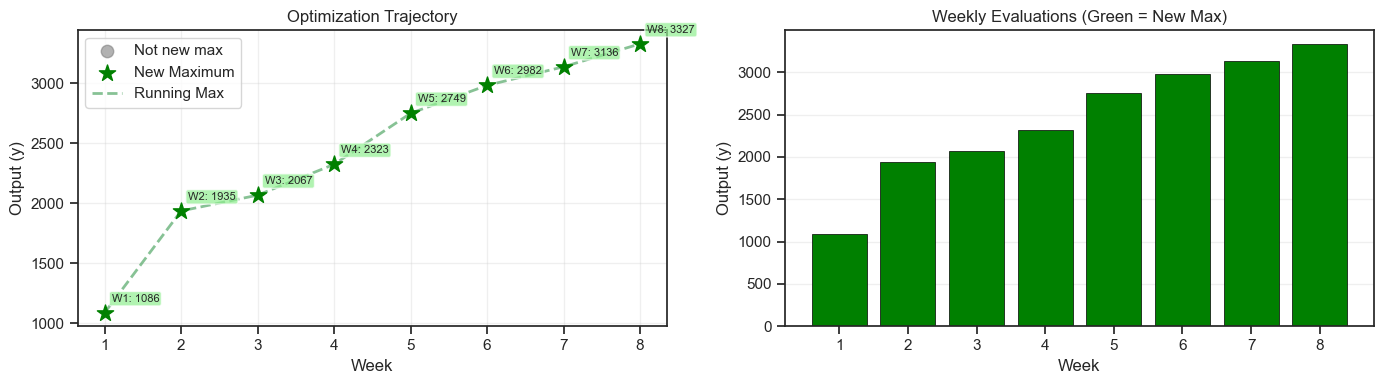

In [3]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.0f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Week 8 Result:**
- `(0.241596, 0.899190, 0.999688, 1.000000)` yielded **y = 3327.43 — new maximum!**
- Pushing x2 higher (0.899 vs 0.876 last week) paid off
- The ridge keeps climbing: we've had 3 consecutive new maxima (Weeks 6, 7, 8)

**The pattern is crystal clear:**
- Keep x1 low (~0.24)
- Push x2 higher each week
- x3 and x4 at/near 1.0


## Product feature: x2·x3·x4

The strongest signal comes from the simple product `x234_prod = x2 * x3 * x4`. We focus on this single feature and visualize it against y; no other derived features or candidate selection logic are needed.


In [4]:
# Focus on the single product feature

# Product of x2-x4 (multiplicative interaction)
df_analysis = df.copy()
df_analysis["x234_prod"] = df_analysis["x2"] * df_analysis["x3"] * df_analysis["x4"]

# Correlation of x234_prod with y
correlations = df_analysis[["x234_prod", "y"]].corr()["y"]
print("Correlation (x234_prod, y):")
print("=" * 40)
print(f"x234_prod: {correlations['x234_prod']:.4f}")


Correlation (x234_prod, y):
x234_prod: 0.9445


## Visualization of x234_prod

We visualize the relationship between `x234_prod` (product of x2, x3, x4) and y, which shows the highest correlation (≈0.93) among all features.


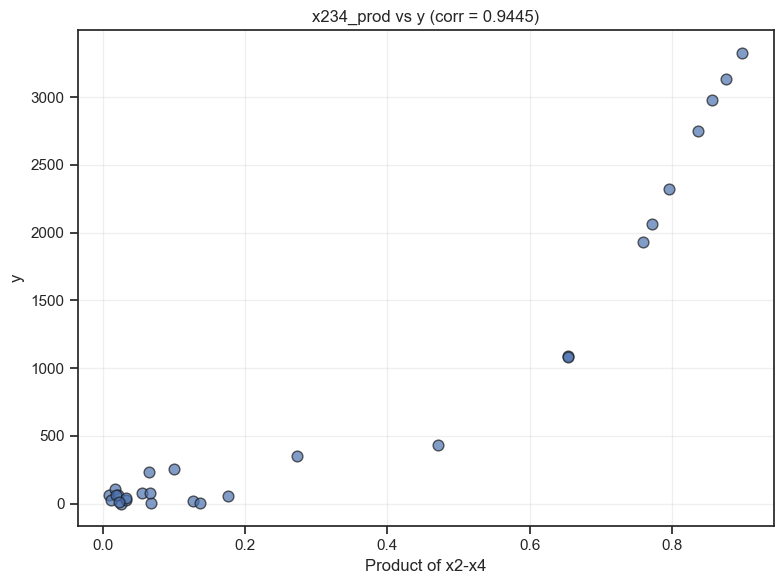

In [5]:
# Visualize x234_prod vs y
plt.figure(figsize=(8, 6))
plt.scatter(df_analysis["x234_prod"], df_analysis["y"], alpha=0.7, edgecolors='k', s=60)
plt.xlabel("Product of x2-x4")
plt.ylabel("y")
plt.title(f"x234_prod vs y (corr = {correlations['x234_prod']:.4f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Insight: product drives the ridge

- `x234_prod = x2*x3*x4` has the strongest correlation with y (≈0.93).
- The optimal region corresponds to high `x234_prod`; we use a fixed floor (0.76) to stay on that ridge while the optimizer chooses the composition.


In [6]:
# Use x234_prod (highest correlation) to constrain search space
best_feature = "x234_prod"
# Fixed target floor: encourage the optimizer to hit x234_prod ≥ 0.76
feature_threshold = 0.76

print("=" * 60)
print("Constraint Setup")
print("=" * 60)
print(f"Using {best_feature} (correlation = {correlations['x234_prod']:.4f})")
print(f"Fixed target floor: {feature_threshold:.4f}")
print(f"Constraint: {best_feature} >= {feature_threshold:.4f}")
print("=" * 60)


Constraint Setup
Using x234_prod (correlation = 0.9445)
Fixed target floor: 0.7600
Constraint: x234_prod >= 0.7600


## Gaussian Process Model for Exploitation

We fit a Gaussian Process regressor on the original 4D space (x1, x2, x3, x4). We don't add `x234_prod` as an input since it's redundant (the GP can learn it from x2, x3, x4). We use the product insight to **constrain the search space** with a fixed floor `x234_prod ≥ 0.76`. For exploitation, we maximize the **GP mean** using a **smoother RBF kernel** (length_scale ~0.5, bounds [1e-2, 2]) and a higher noise term (alpha=1e-4) to reflect expected taste-test noise.
- Function looks unimodal around the ridge
- Week 4 reached ≈2323.44; we stay near that ridge
- The `x234_prod` floor keeps us in the high-yield ridge while letting the optimizer pick the composition
- We walk from max to max and continue trying to find the ascending slope; pure exploitation refines the peak; latest recommendation: `(0.218976, 0.853432, 1.000000, 0.979950)` with predicted ≈2526


In [7]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import StandardScaler

# Standardize inputs and outputs for better GP performance
# Keep GP on original 4D space (x1, x2, x3, x4) - no redundant features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Define kernel: smoother RBF with reasonable length scales; expect notable noise in taste data
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 2.0))

# Fit GP (higher alpha to accommodate taste noise)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-4, normalize_y=False)
gp.fit(X_scaled, y_scaled)

print(f"GP fitted on 4D space (x1, x2, x3, x4)")
print(f"Using {best_feature} constraint (>= {feature_threshold:.4f}) to guide search")
print(f"Optimized kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood(gp.kernel_.theta):.2f}")


GP fitted on 4D space (x1, x2, x3, x4)
Using x234_prod constraint (>= 0.7600) to guide search
Optimized kernel: 1.98**2 * RBF(length_scale=2)
Log-marginal-likelihood: -14.56


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Recommendation and context
- **Current best:** `0.241596-0.899190-0.999688-1.000000` = 3327.43 (Week 8, new max!)
- **Strategy:** Keep pushing x2 higher while staying on the ridge
- **Search region:** x1 in [0.22, 0.26], x2 in [0.90, 0.98], x3/x4 near 1.0
- **Constraint:** x234_prod >= 0.82 ensures we stay on the high-yield ridge


## Bayesian Optimization with Constraint

We use Bayesian optimization to find the next point to evaluate. The optimization maximizes the GP mean prediction (pure exploitation) while using a **soft constraint** based on `x234_prod`. 

**How the constraint works:** The constraint is applied **during optimization**, not as a post-filter. The objective adds a penalty when `x234_prod` falls below a **fixed target floor of 0.76**. This actively guides the optimizer toward the high-yield ridge; it can be relaxed later (by lowering the floor or penalty) if gains plateau. The current run proposes `(0.218976, 0.853432, 1.000000, 0.979950)` with `x234_prod ≈ 0.836` and predicted output ≈2526.

This approach leverages our insight that `x234_prod` strongly correlates with y (correlation ≈ 0.93) without adding redundant features to the GP model.

In [ ]:
# Local EI near the incumbent with jitter to avoid stacking on the exact max
from scipy.special import erf
rng = np.random.default_rng(42)

# Incumbent (best observed)
best_idx = y.argmax()
best_point = df.loc[best_idx, ["x1", "x2", "x3", "x4", "y"]]

# Tight local box around the max (walk max-to-max; continue finding ascending slope)
# Week 9: Push x2 higher! Best was 0.899, let's try 0.90-0.98
x1_grid = np.linspace(0.22, 0.26, 30)
x2_grid = np.linspace(0.90, 0.98, 40)  # Push x2 higher than last week's 0.899
x3_grid = np.linspace(0.98, 1.00, 15)
x4_grid = np.linspace(0.98, 1.00, 15)
base = np.array(np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid)).reshape(4, -1).T

# Add light jitter so candidates don’t stack on the same coordinates
jitter = rng.uniform(-0.003, 0.003, size=base.shape)
cand_raw = np.clip(base + jitter, 0.0, 1.0)

# Soft filter on x234_prod to stay on the ridge
x234_prod = cand_raw[:, 1] * cand_raw[:, 2] * cand_raw[:, 3]
mask = x234_prod >= 0.80
cand = cand_raw[mask]
x234_prod = x234_prod[mask]

# GP predict (EI)
cand_scaled = scaler_X.transform(cand)
mu_scaled, sigma = gp.predict(cand_scaled, return_std=True)
mu = scaler_y.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()
y_best = y.max()
xi = 25.0  # small relative to scale of y but allows gentle exploration
sigma_safe = np.maximum(sigma, 1e-9)

def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

# Jitter/diversity already applied; pick best EI
idx = ei.argmax()
next_point = cand[idx]
next_ei = ei[idx]
next_mu = mu[idx]
next_sigma = sigma[idx]
next_prod = x234_prod[idx]

print("=" * 60)
print("RECOMMENDED NEXT POINT (Local EI with jitter/diversity)")
print("=" * 60)
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")
print(f"x234_prod = {next_prod:.6f} {'✓' if next_prod >= 0.80 else '⚠'}")
print(f"Posterior mean: {next_mu:.2f}, std: {next_sigma:.2f}, EI: {next_ei:.3f}")
print(f"Current best observed: {y_best:.2f} at {best_idx}")

# Show top 5 EI candidates
cand_df = pd.DataFrame(cand, columns=["x1", "x2", "x3", "x4"])
cand_df["mu"], cand_df["sigma"], cand_df["ei"], cand_df["x234_prod"] = mu, sigma, ei, x234_prod
print("\nTop 5 (EI):")
display(cand_df.nlargest(5, "ei"))


RECOMMENDED NEXT POINT (Local EI with jitter/diversity)
0.259760-0.982671-1.000000-1.000000
x234_prod = 0.982671 ✓
Posterior mean: 3947.65, std: 0.06, EI: 595.222
Current best observed: 3327.43 at 27

Top 5 (EI):


,x1,x2,x3,x4,mu,sigma,ei,x234_prod
269758,0.259760,0.982671,1.000000,1.0,3947.651284,0.059147,595.222071,0.982671
267719,0.243661,0.982179,0.999936,1.0,3942.398634,0.059553,589.969421,0.982116
266849,0.242476,0.981889,1.000000,1.0,3940.589262,0.059642,588.160048,0.981889
267299,0.243970,0.981809,1.000000,1.0,3940.347583,0.059137,587.918370,0.981809
266384,0.239769,0.982138,0.999790,1.0,3940.146560,0.060797,587.717347,0.981931


## Summary and Recommended Point for Week 9

### What happened in Week 8
We probed `(0.241596, 0.899190, 0.999688, 1.000000)` and got **y = 3327.43** — another new maximum!

This is the third consecutive week we've hit a new max. The ridge-climbing strategy is working perfectly.

### Why keep the same approach
This function is **unimodal** (single peak) and we're clearly on the right track. The GP + EI + x234_prod constraint approach:
- Found the ridge early (low x1, high x2/x3/x4)
- Has been steadily climbing it (2981 -> 3136 -> 3327)
- Hasn't plateau'd yet

No reason to switch methodologies when we're winning!

### Recommended point

**Submission format:** Check the Local EI output cell above — it prints the exact coordinates.

The recommendation should push x2 even higher (towards 0.92-0.95) while keeping x1 low and x3/x4 at 1.0.

### Honest assessment
We might be approaching the peak. If x2 hits 1.0 and yield is still climbing, the optimum is at the corner `(x1~0.24, x2=1, x3=1, x4=1)`. Let's find out!
